In [1]:
from mainnet_launch.pages.asset_discounts.stable_coin_pricing import (
    StableCoinConsants,
    stablecoin_constants,
    build_balancer_query_swap_call,
)
from mainnet_launch.data_fetching.get_state_by_block import (
    get_raw_state_by_blocks,
    get_state_by_one_block,
    build_blocks_to_use,
    _build_blocks_to_use_dont_clip,
)
from mainnet_launch.constants import ETH_CHAIN
import plotly.express as px
import plotly.io as pio
import pandas as pd

pio.templates.default = None
import numpy as np

blocks = build_blocks_to_use(ETH_CHAIN, start_block=20689810)


def build_stable_coin_safe_prices(stablecoin_constants: list[StableCoinConsants], blocks: list[int]) -> pd.DataFrame:
    backing_calls = [c.backing_call for c in stablecoin_constants]
    safe_price_calls = [c.safe_price_call for c in stablecoin_constants if c.safe_price_call is not None]
    df = get_raw_state_by_blocks([*backing_calls, *safe_price_calls], blocks, ETH_CHAIN, include_block_number=True)
    df["sUSDs_safe_price"] = df["sUSDs_backing"] * df["USDs_safe_price"]
    df["scrvUSD_safe_price"] = df["scrvUSD_backing"] * df["crvUSD_safe_price"]
    df["sUSDe_safe_price"] = df["sUSDe_backing"] * df["USDe_safe_price"]
    return df


def build_stable_coin_spot_price(stablecoin_constants: list[StableCoinConsants], blocks: list[int]) -> pd.DataFrame:
    spot_price_calls = [
        call
        for calls in [c.spot_price_calls for c in stablecoin_constants if c.spot_price_calls is not None]
        for call in calls
    ]

    backing_calls = [c.backing_call for c in stablecoin_constants]

    safe_price_calls = [c.safe_price_call for c in stablecoin_constants if c.safe_price_call is not None]

    df = get_raw_state_by_blocks(
        [*backing_calls, *safe_price_calls, *spot_price_calls], blocks, ETH_CHAIN, include_block_number=True
    )

    df["sUSDs_safe_price"] = df["sUSDs_backing"] * df["USDs_safe_price"]
    df["scrvUSD_safe_price"] = df["scrvUSD_backing"] * df["crvUSD_safe_price"]
    df["sUSDe_safe_price"] = df["sUSDe_backing"] * df["USDe_safe_price"]

    # safe price for USDs on day 1 is an outlier, at 1.2, igoring
    df.loc[df["USDs_safe_price"] == df["USDs_safe_price"].max(), "USDs_safe_price"] = np.nan

    df = df.replace(0, np.nan)

    return df


df = build_stable_coin_spot_price(stablecoin_constants, blocks)
raw_df = df.copy()

[Errno 1] [SSL: SSLV3_ALERT_BAD_RECORD_MAC] sslv3 alert bad record mac (_ssl.c:2548) [0]
[Errno 1] [SSL: SSLV3_ALERT_BAD_RECORD_MAC] sslv3 alert bad record mac (_ssl.c:2548) [0]
[Errno 1] [SSL: SSLV3_ALERT_BAD_RECORD_MAC] sslv3 alert bad record mac (_ssl.c:2548) [0]


In [9]:
def _extract_safe_and_spot_prices(df: pd.DataFrame):
    # USDC
    df["USDC_spot_price"] = 1.0

    # USDT
    df["USDT_spot_price"] = df[["USDT_to_USDC_spot_price", "USDT_to_USDC_spot_price2"]].max(axis=1)

    # DAI
    df["DAI_spot_price"] = df[["DAI_to_USDC_spot_price", "DAI_to_USDC_spot_price2"]].max(axis=1)

    # USDe and sUSDe
    df["USDe_to_USDC_spot_price2"] = df["sUSDe_to_USDC_spot_price"].div(df["sUSDe_backing"])
    df["USDe_spot_price"] = df[["USDe_to_USDC_spot_price", "USDe_to_USDC_spot_price2"]].max(axis=1)
    df["sUSDe_spot_price"] = df["USDe_spot_price"] * df["sUSDe_backing"]

    # crvUSD, scrvUSD
    df["crvUSD_to_USDC_spot_price2"] = df["crvUSD_to_USDT_spot_price"] * df["USDT_safe_price"]

    df["crvUSD_spot_price"] = df[["crvUSD_to_USDC_spot_price", "crvUSD_to_USDC_spot_price2"]].max(axis=1)
    df["scrvUSD_spot_price"] = df["crvUSD_spot_price"] * df["scrvUSD_backing"]

    # USDs and sUSDs is a special case
    df["sUSDs_to_USDC_spot_price"] = df["sUSDS_to_FRAX_spot_price"] * df["FRAX_safe_price"]
    df["USDs_to_USDC_spot_price2"] = df["sUSDs_to_USDC_spot_price"].div(df["sUSDs_backing"])

    # df["USDs_spot_price"] = df[["sUSD_to_USDC_spot_price", "USDs_to_USDC_spot_price2"]].max(axis=1)
    df["USDs_spot_price"] = df[["USDs_to_USDC_spot_price2"]].max(axis=1)
    df["sUSDs_spot_price"] = df["USDs_spot_price"] * df["sUSDs_backing"]

    # GHO
    df["GHO_to_USDC_spot_price2"] = df["GHO_to_crvUSD_spot_price"] * df["crvUSD_safe_price"]

    df["GHO_spot_price"] = df[["GHO_to_USDC_spot_price", "GHO_to_USDC_spot_price2"]].max(axis=1)

    # FRAX and sFRAX
    df["sFRAX_to_USDC_spot_price"] = df["sFRAX_to_crvUSD_spot_price"] * df["crvUSD_safe_price"]
    df["FRAX_to_USDC_spot_price"] = df["sFRAX_to_USDC_spot_price"].div(df["sFRAX_backing"])
    df["FRAX_to_USDC_spot_price2"] = df["FRAX_to_USDe_spot_price"] * df["USDe_safe_price"]

    df["FRAX_spot_price"] = df[["FRAX_to_USDC_spot_price", "FRAX_to_USDC_spot_price2"]].max(axis=1)
    df["sFRAX_spot_price"] = df["FRAX_spot_price"] * df["sFRAX_backing"]

    token_symbols = ["USDC", "USDT", "DAI", "USDe", "crvUSD", "USDs", "GHO", "FRAX"]
    spot_price_df = df[
        [
            "USDC_spot_price",
            "USDT_spot_price",
            "DAI_spot_price",
            "USDe_spot_price",
            "crvUSD_spot_price",
            "USDs_spot_price",
            "GHO_spot_price",
            "FRAX_spot_price",
        ]
    ].copy()

    spot_price_df.columns = token_symbols

    safe_price_df = df[
        [
            "USDC_safe_price",
            "USDT_safe_price",
            "DAI_safe_price",
            "USDe_safe_price",
            "crvUSD_safe_price",
            "USDs_safe_price",
            "GHO_safe_price",
            "FRAX_safe_price",
        ]
    ].copy()
    safe_price_df.columns = token_symbols

    long_safe_prices = safe_price_df.reset_index().melt(id_vars="timestamp", var_name="token", value_name="safe_price")
    long_spot_prices = spot_price_df.reset_index().melt(id_vars="timestamp", var_name="token", value_name="spot_price")

    long_df = pd.merge(long_spot_prices, long_safe_prices, on=["timestamp", "token"])
    long_df["backing"] = 1.0
    return long_df, safe_price_df, spot_price_df


long_df, safe_price_df, spot_price_df = _extract_safe_and_spot_prices(df)

In [3]:
# DAI:USDS pool

# Safe USDS -> USDC

# 1 Dai -> X USDS * safe price USDS safe =

# spot price of DAI in this pool is 

In [4]:
#

In [5]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

for n_days in [1, 3, 7]:
    for price_df, name in zip([spot_price_df, safe_price_df], ["Spot Prices", "Safe Prices"]):

        moving_average_df = price_df.rolling(n_days).mean()

        # Set the grid dimensions
        rows = 3
        cols = 3

        # Create the subplots grid with subplot titles using the column names
        fig = make_subplots(rows=rows, cols=cols, subplot_titles=list(moving_average_df.columns))

        # Loop over each column and add its trace to the correct subplot cell
        for i, col in enumerate(moving_average_df.columns):
            # Calculate grid position: row and column
            row = i // cols + 1
            col_pos = i % cols + 1

            # Create a line plot for the column using px.line
            temp_fig = px.line(moving_average_df, y=col)

            # Add the traces from the temporary figure into the subplot cell
            for trace in temp_fig.data:
                fig.add_trace(trace, row=row, col=col_pos)

        fig.update_yaxes(range=[0.95, 1.02])
        fig.update_layout(
            height=300 * rows, width=400 * cols, title_text=f"{n_days} Day Moving Average {name}", showlegend=False
        )

        fig.show()

In [ ]:
# 

In [6]:
def make_safe_price_premium_and_discount_df(long_df: pd.DataFrame) -> pd.DataFrame:
    local_long_df = long_df.copy()

    local_long_df["percent_off_from_peg"] = 100 * (local_long_df["safe_price"] - local_long_df["backing"])

    local_long_df["discount < -10bps"] = local_long_df["percent_off_from_peg"] < -0.1
    local_long_df["discount < -20bps"] = local_long_df["percent_off_from_peg"] < -0.2
    local_long_df["discount < -50bps"] = local_long_df["percent_off_from_peg"] < -0.5
    local_long_df["discount < -100bps"] = local_long_df["percent_off_from_peg"] < -1

    # Create new columns with shorter names for premium conditions
    local_long_df["premium > 10bps"] = local_long_df["percent_off_from_peg"] > 0.1
    local_long_df["premium > 20bps"] = local_long_df["percent_off_from_peg"] > 0.2
    local_long_df["premium > 50bps"] = local_long_df["percent_off_from_peg"] > 0.5
    local_long_df["premium > 100bps"] = local_long_df["percent_off_from_peg"] > 1

    # Update the list of columns accordingly
    columns = [
        "discount < -10bps",
        "discount < -20bps",
        "discount < -50bps",
        "discount < -100bps",
        "premium > 10bps",
        "premium > 20bps",
        "premium > 50bps",
        "premium > 100bps",
    ]

    percentage_dfs = []

    for col in columns:

        a_check_df = 100 * (local_long_df.groupby("token")[col].sum() / local_long_df.groupby("token")[col].count())
        a_check_df.name = col
        percentage_dfs.append(a_check_df)

    percent_df = pd.concat(percentage_dfs, axis=1)
    return percent_df.round(1)


safe_price_discount_df = make_safe_price_premium_and_discount_df(long_df)
safe_price_discount_df

,discount < -10bps,discount < -20bps,discount < -50bps,discount < -100bps,premium > 10bps,premium > 20bps,premium > 50bps,premium > 100bps
token,,,,,,,,
DAI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FRAX,100.0,97.3,3.3,0.0,0.0,0.0,0.0,0.0
GHO,39.3,19.1,6.0,1.6,9.8,7.7,3.3,0.0
USDC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
USDT,10.4,1.1,0.0,0.0,3.8,0.0,0.0,0.0
USDe,21.9,5.5,0.0,0.0,21.9,4.4,0.0,0.0
USDs,27.9,18.6,4.4,0.0,18.6,11.5,2.7,1.6
crvUSD,51.9,25.1,3.3,0.0,0.5,0.0,0.0,0.0


In [7]:
def make_safe_and_spot_spread_diff(long_df: pd.DataFrame) -> pd.DataFrame:
    local_long_df = long_df.copy()

    local_long_df["percent_off_from_peg"] = (
        100 * (local_long_df["safe_price"] - local_long_df["spot_price"]) / long_df["safe_price"]
    )

    local_long_df["discount < -10bps"] = local_long_df["percent_off_from_peg"] < -0.1
    local_long_df["discount < -20bps"] = local_long_df["percent_off_from_peg"] < -0.2
    local_long_df["discount < -50bps"] = local_long_df["percent_off_from_peg"] < -0.5
    local_long_df["discount < -100bps"] = local_long_df["percent_off_from_peg"] < -1

    # Create new columns with shorter names for premium conditions
    local_long_df["premium > 10bps"] = local_long_df["percent_off_from_peg"] > 0.1
    local_long_df["premium > 20bps"] = local_long_df["percent_off_from_peg"] > 0.2
    local_long_df["premium > 50bps"] = local_long_df["percent_off_from_peg"] > 0.5
    local_long_df["premium > 100bps"] = local_long_df["percent_off_from_peg"] > 1

    # Update the list of columns accordingly
    columns = [
        "discount < -10bps",
        "discount < -20bps",
        "discount < -50bps",
        "discount < -100bps",
        "premium > 10bps",
        "premium > 20bps",
        "premium > 50bps",
        "premium > 100bps",
    ]

    percentage_dfs = []

    for col in columns:

        a_check_df = 100 * (local_long_df.groupby("token")[col].sum() / local_long_df.groupby("token")[col].count())
        a_check_df.name = col
        percentage_dfs.append(a_check_df)

    percent_df = pd.concat(percentage_dfs, axis=1)
    return percent_df.round(1)


safe_and_spot_spread_df = make_safe_and_spot_spread_diff(long_df)
safe_and_spot_spread_df

,discount < -10bps,discount < -20bps,discount < -50bps,discount < -100bps,premium > 10bps,premium > 20bps,premium > 50bps,premium > 100bps
token,,,,,,,,
DAI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FRAX,7.7,0.5,0.0,0.0,2.2,0.0,0.0,0.0
GHO,30.1,13.7,2.7,2.2,6.6,1.1,0.0,0.0
USDC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
USDT,2.2,0.0,0.0,0.0,0.5,0.0,0.0,0.0
USDe,2.2,0.0,0.0,0.0,3.3,0.0,0.0,0.0
USDs,29.0,24.0,10.9,4.9,57.4,53.6,50.3,37.2
crvUSD,5.5,2.2,0.0,0.0,2.2,0.0,0.0,0.0


In [8]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

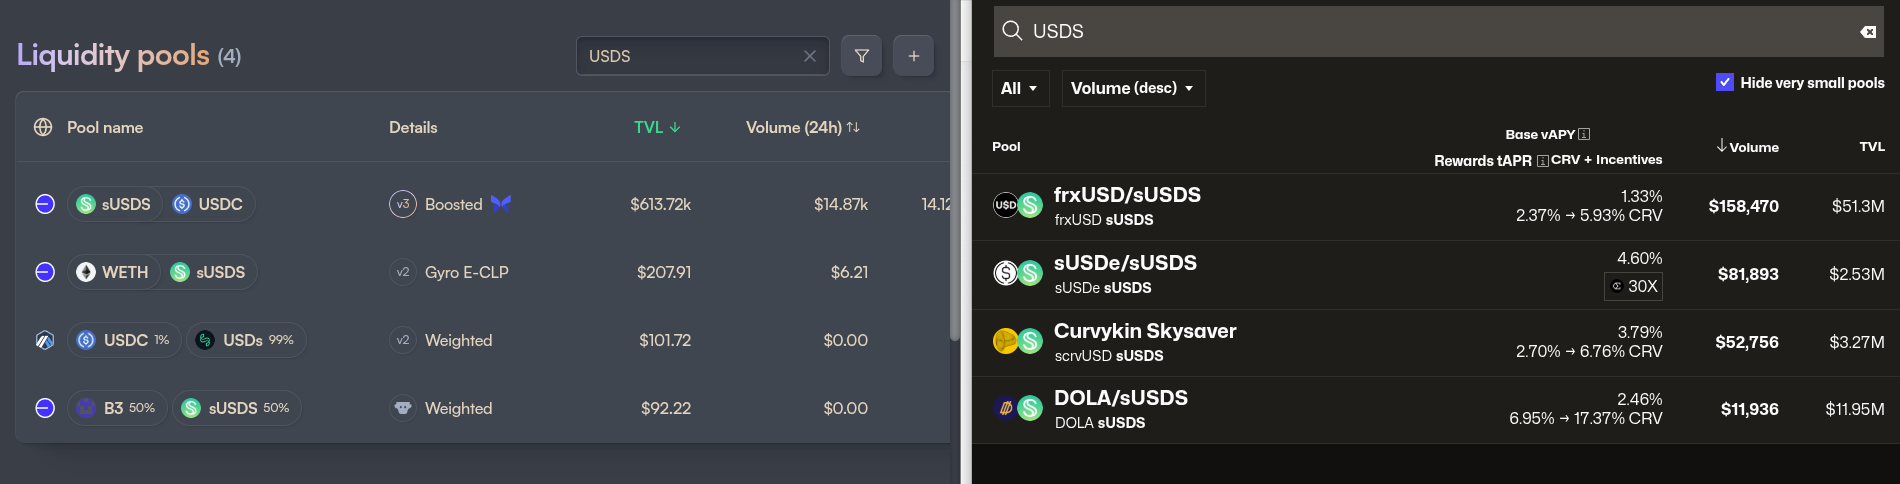

There is no liqudity for USDS on curve or balancer

In [ ]:
# frxETH/sUSDs started on feb 19 days old https://etherscan.io/tx/0x1337bb704ce15d22664b646855a4b3c7ff484ca79f34de0cea16f04190e54e0e
# because of the Peg stablity module, most of the liqudity

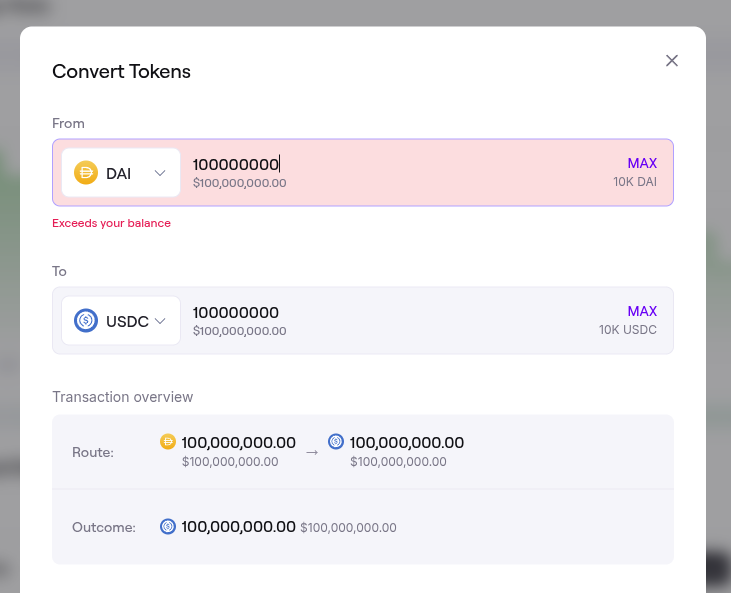

100M DAI for USDC

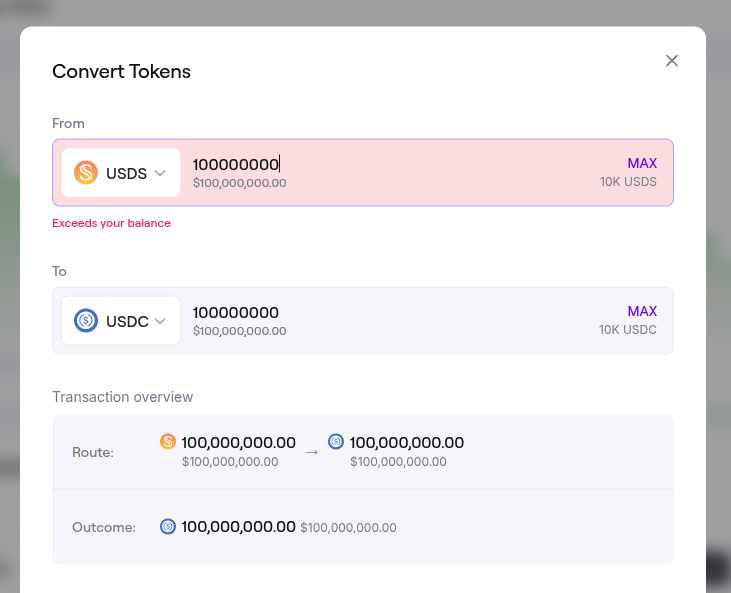
100M DAI for USDC on mainnet at no slippage

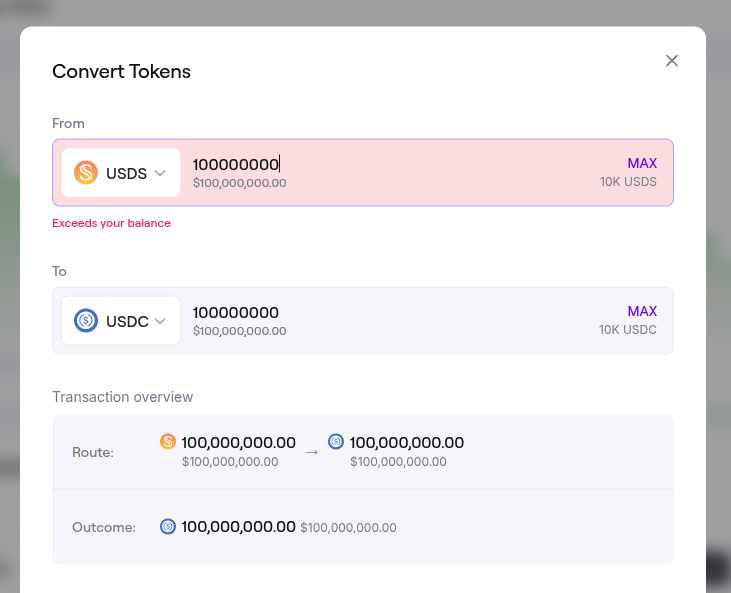

100M USDS for USDC on mainnet at no slippage

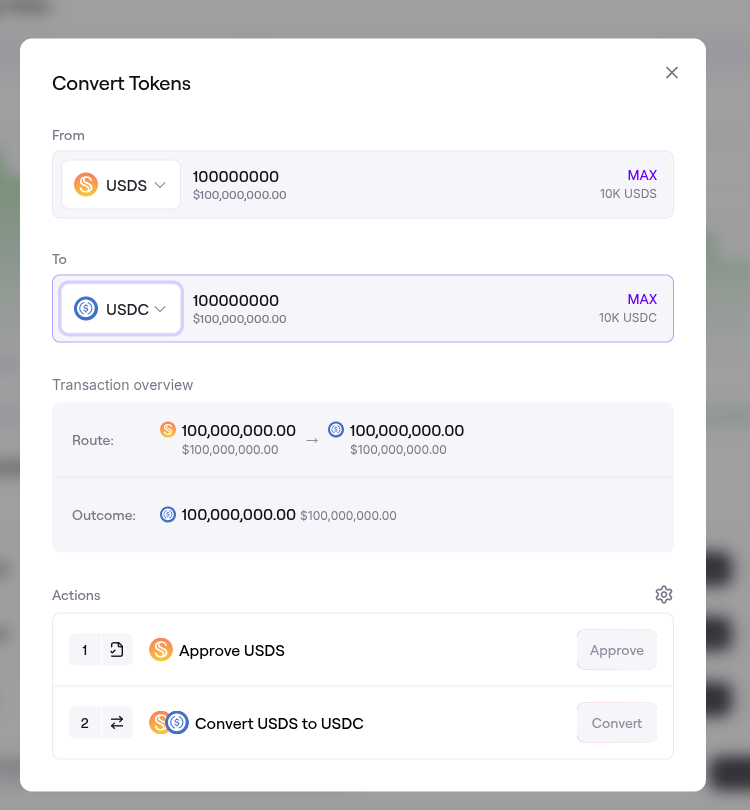

In [ ]:
safe_price_df[["USDC", "DAI", "USDs"]].head(10)

In [ ]:
# value of sUSDs in frxETH 

In [ ]:
# understand the peg stablity module for this pool
# it seems like we use the 1:1 route 99% of the time, since getting .9999 DAI for each USDC
#

# DAI -> USDC, compare the curve pool and the PSM


# Codebase

# Deployment Addresses

# Details

# Converts DAI to USDS at a fixed ratio of 1:1 and vice versa.

# No fees assessed.

# Fees cannot be enabled on this route in the future.


# https://etherscan.io/address/0x3225737a9Bbb6473CB4a45b7244ACa2BeFdB276A


# It's all about DAI:USDs

In [ ]:
# I think AAVE used USDs: DAI price feed
@#https://governance.aave.com/t/technical-maintenance-proposals/15274/45

In [ ]:
px.line(safe_price_df)

In [ ]:
pirceimpor

In [ ]:
# Ethena owns a lot of sUSDs
# 0x2d4d2a025b10c09bdbd794b4fce4f7ea8c7d7bb4

# https://etherscan.io/address/0x7f311a4d48377030bd810395f4ccfc03bdbe9ef3#code

In [ ]:
# This is a special case. check the transfer volumne of DAI vs all the others

In [ ]:
sp

In [ ]:
def build_

In [ ]:
px.line(spot_price_df[["crvUSD_to_USDC_spot_price", "crvUSD_to_USDT_spot_price"]])

In [ ]:
# def fetch_stable_coin_spot_safe_and_backing():

#     # # 100 * (peg - safe) / peg
#     # for symbol in token_symbols:
#     #     df[f"{symbol}_discount"] = 100 * ((df[f"{symbol}_backing"] - df[f"{symbol}_safe_price"]) / df[f"{symbol}_backing"])

#     discount_cols = [c for c in df.columns if "_discount" in c]
#     px.line(df[discount_cols], title="stablecoin percent discoutns")

#     spot_price_calls = [
#         call
#         for calls in [c.spot_price_calls for c in stablecoin_constants if c.spot_price_calls is not None]
#         for call in calls
#     ]
#     spot_price_df = get_raw_state_by_blocks(spot_price_calls, blocks, ETH_CHAIN)
#     full_df = pd.concat([df, spot_price_df], axis=1)

#     full_df["DAI_spot_price"] = full_df[["DAI_to_USDC_spot_price", "DAI_to_USDC_spot_price2"]].max(axis=1)
#     full_df["USDs_spot_price"] = full_df["DAI_spot_price"]  # dai is 1:1 with USDs

#     full_df["USDe_to_USDC_spot_price2"] = full_df["sUSEe_to_USDC_spot_price"].divide(full_df["sUSDe_backing"])
#     full_df["USDe_spot_price"] = full_df[["USDe_to_USDC_spot_price", "USDe_to_USDC_spot_price2"]].max(axis=1)

#     full_df["USDC_spot_price"] = 1.0  # by definition

#     full_df["USDT_spot_price"] = full_df[["USDT_to_USDC_spot_price", "USDT_to_USDC_spot_price2"]].max(axis=1)
#     full_df["GHO_spot_price"] = full_df[["GHO_to_USDC_spot_price"]].max(axis=1)
#     full_df["crvUSD_to_USDC_spot_price2"] = full_df["crvUSD_to_USDT_spot_price"] * full_df["USDT_spot_price"]

#     full_df["crvUSD_spot_price"] = full_df[["crvUSD_to_USDC_spot_price", "crvUSD_to_USDC_spot_price2"]].max(axis=1)

#     full_df["scrvUSD_spot_price"] = full_df["crvUSD_spot_price"] * full_df["scrvUSD_backing"]
#     full_df["sUSDe_spot_price"] = full_df["USDe_spot_price"] * full_df["sUSDe_backing"]

#     return full_df


# df = fetch_stable_coin_spot_safe_and_backing()

# df

In [ ]:
safe_price_cols = [f"{t}_safe_price" for t in token_symbols]
backing_cols = [f"{t}_backing" for t in token_symbols]
spot_price_cols = [f"{t}_spot_price" for t in token_symbols]
df[[*spot_price_cols, *spot_price_cols, *backing_cols]].to_csv("stable_coin_prices.csv")

percent_difference_from_peg_in_safe = pd.DataFrame(
    data=100 * (df[backing_cols].values - df[safe_price_cols].values) / (df[backing_cols].values),
    columns=token_symbols,
    index=df.index,
)
percent_difference_from_peg_in_safe.to_csv("percent_difference_from_peg_in_safe.csv")

percent_difference_between_safe_and_spot = pd.DataFrame(
    data=100 * (df[safe_price_cols].values - df[spot_price_cols].values) / (df[safe_price_cols].values),
    columns=token_symbols,
    index=df.index,
)
percent_difference_between_safe_and_spot.to_csv("percent_difference_between_safe_and_spot.csv")

percent_difference_from_peg_in_spot = pd.DataFrame(
    data=100 * (df[backing_cols].values - df[spot_price_cols].values) / (df[backing_cols].values),
    columns=token_symbols,
    index=df.index,
)
percent_difference_from_peg_in_spot.to_csv("percent_difference_from_peg_in_spot.csv")

px.line(percent_difference_from_peg_in_spot, title="100 * (backing - spot_price) / backing").show()
px.line(percent_difference_from_peg_in_safe, title="100 * (backing - safe price) / backing").show()
px.line(percent_difference_between_safe_and_spot, title="100 * (safe price - spot_price) / spot price").show()

In [ ]:
px.ecdf(percent_difference_from_peg_in_spot, title="100 * (backing - spot_price) / backing").show()
px.ecdf(percent_difference_from_peg_in_safe, title="100 * (backing - safe price) / backing").show()
px.ecdf(percent_difference_between_safe_and_spot, title="100 * (safe price - spot_price) / spot price").show()

In [ ]:
percent_difference_between_safe_and_spot.describe(percentiles=[0.2, 0.8]).T.round(4) * 100

In [ ]:
px.ecdf(percent_difference_between_safe_and_spot)

In [ ]:
from mainnet_launch.constants import ETH_CHAIN, ROOT_PRICE_ORACLE

from multicall import Call

from mainnet_launch.data_fetching.get_state_by_block import (
    safe_normalize_6_with_bool_success,
    safe_normalize_with_bool_success,
)

USDC = "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48"


def build_root_price_oracle_to_USDC_call(token_address: str, name: str) -> Call:
    return Call(
        ROOT_PRICE_ORACLE(ETH_CHAIN),
        ["getPriceInQuote(address,address)(uint256)", ETH_CHAIN.client.toChecksumAddress(token_address), USDC],
        [(name, safe_normalize_6_with_bool_success)],
    )


calls = [
    build_root_price_oracle_to_USDC_call(c.token_address, f"{c.token_address} {c.symbol}") for c in stablecoin_constants
]
get_state_by_one_block(calls, 22033308 + 1, ETH_CHAIN)

In [ ]:
# DAI, USDC

In [ ]:
def build_get_price_in_eth_call(token_address: str, name: str) -> Call:
    return Call(
        ROOT_PRICE_ORACLE(ETH_CHAIN),
        ["getPriceInQuote(address,address)(uint256)", ETH_CHAIN.client.toChecksumAddress(token_address), USDC],
        [(name, safe_normalize_6_with_bool_success)],
    )


calls = [
    build_root_price_oracle_to_USDC_call(c.token_address, f"{c.token_address} {c.symbol}") for c in stablecoin_constants
]
get_state_by_one_block(calls, 22033308 + 1, ETH_CHAIN)

In [ ]:
# RootPriceOracle.getPriceInQuote(base, quote) -> uses chainlink

In [ ]:
ROOT_PRICE_ORACLE(ETH_CHAIN), USDC

In [ ]:
blocks = build_blocks_to_use(ETH_CHAIN)

In [ ]:
import numpy as numpy

numpy.median(blocks)

In [ ]:
get_state_by_one_block(calls, 21400535, ETH_CHAIN)  # Dec 14th

In [ ]:
get_state_by_one_block(calls, 22033308 + 1, ETH_CHAIN)

In [ ]:
stablecoin_constants

In [ ]:
ROOT_PRICE_ORACLE(ETH_CHAIN)

In [ ]:
pass

In [ ]:
DAI_to_USDC_spot_price = Call(
    "0xbEbc44782C7dB0a1A60Cb6fe97d0b483032FF1C7",
    ["get_dy(int128,int128,uint256)(uint256)", 0, 1, int(1e18)],
    [("DAI_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)

DAI_to_USDC_spot_price2 = Call(
    "0xA5407eAE9Ba41422680e2e00537571bcC53efBfD",
    ["get_dy(int128,int128,uint256)(uint256)", 0, 1, int(1e18)],
    [("DAI_to_USDC_spot_price2", safe_normalize_6_with_bool_success)],
)


USDT_to_USDC_spot_price = Call(
    "0xbEbc44782C7dB0a1A60Cb6fe97d0b483032FF1C7",
    ["get_dy(int128,int128,uint256)(uint256)", 2, 1, int(1e6)],
    [("USDT_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)

USDT_to_USDC_spot_price_2 = Call(
    "0xA5407eAE9Ba41422680e2e00537571bcC53efBfD",
    ["get_dy(int128,int128,uint256)(uint256)", 2, 1, int(168)],
    [("USDT_to_USDC_spot_price_2", safe_normalize_6_with_bool_success)],
)


crvUSD_to_USDC_spot_price = Call(
    "0x4DEcE678ceceb27446b35C672dC7d61F30bAD69E",
    ["get_dy(int128,int128,uint256)(uint256)", 1, 0, int(1e18)],
    [("crvUSD_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)


crvUSD_to_USDT_spot_price = Call(
    "0x390f3595bCa2Df7d23783dFd126427CCeb997BF4",
    ["get_dy(int128,int128,uint256)(uint256)", 1, 0, int(1e18)],
    [("crvUSD_to_USDT_spot_price", safe_normalize_6_with_bool_success)],
)


USDe_to_USDC_spot_price = Call(
    "0x02950460E2b9529D0E00284A5fA2d7bDF3fA4d72",
    ["get_dy(int128,int128,uint256)(uint256)", 0, 1, int(1e18)],
    [("USDe_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)


sUSD_to_USDC_spot_price = Call(
    "0xA5407eAE9Ba41422680e2e00537571bcC53efBfD",
    ["get_dy(int128,int128,uint256)(uint256)", 3, 1, int(1e18)],
    [("sUSD_to_USDC_spot_price", safe_normalize_6_with_bool_success)],
)


# balancer GHO -> USDC
# https://balancer.fi/pools/ethereum/v2/0x8353157092ed8be69a9df8f95af097bbf33cb2af0000000000000000000005d9

# https://balancer.fi/pools/ethereum/v2/0x8353157092ed8be69a9df8f95af097bbf33cb2af0000000000000000000005d9
# USDT, GHO, USDC


calls = [
    crvUSD_to_USDC_spot_price,
    USDe_to_USDC_spot_price,
    DAI_to_USDC_spot_price,
    USDT_to_USDC_spot_price,
]

get_state_by_one_block(calls, max(blocks), ETH_CHAIN)

In [ ]:
# s  # sUSDe -> usdc https://balancer.fi/pools/ethereum/v2/0xb819feef8f0fcdc268afe14162983a69f6bf179e000000000000000000000689

# gho, USDC, USDT tri pool  https://balancer.fi/pools/ethereum/v2/0x8353157092ed8be69a9df8f95af097bbf33cb2af0000000000000000000005d9

# https://curve.fi/dex/ethereum/pools/factory-crvusd-0/deposit/
# crvUSD -> USDC


# dai, USDC, USDT tri pool
# https://curve.fi/dex/ethereum/pools/3pool/deposit/

# USDe -> USDC https://curve.fi/dex/ethereum/pools/factory-stable-ng-12/deposit/

# USDs does not have good sorces of liquidty


# https://app.uniswap.org/explore/pools/ethereum/0x5777d92f208679DB4b9778590Fa3CAB3aC9e2168

In [ ]:
# from web3 import Web3

# # Assume you have an initialized Web3 instance (e.g. using an Infura or Alchemy endpoint)

# queries_address = Web3.toChecksumAddress("0xE39B5e3B6D74016b2F6A9673D7d7493B6DF549d5")

# pool_id = bytes.fromhex("0xb819feef8f0fcdc268afe14162983a69f6bf179e000000000000000000000689"[2:])
# amount_in = int(1e18)
# swap_kind = 0
# user_data = b""

# from_internal_balance = False
# to_internal_balance = False

# call_obj = Call(
#     "0xE39B5e3B6D74016b2F6A9673D7d7493B6DF549d5",  # Balancer Queries contract address
#     [
#         # Function signature for querySwap with two tuple parameters:
#         "querySwap((bytes32,uint8,address,address,uint256,bytes),(address,bool,address,bool))(uint256)",
#         pool_id,
#         swap_kind,
#         sUSDe,
#         USDC,
#         amount_in,
#         user_data,
#         '0xE39B5e3B6D74016b2F6A9673D7d7493B6DF549d5',
#         from_internal_balance,
#         '0xE39B5e3B6D74016b2F6A9673D7d7493B6DF549d5',
#         to_internal_balance
#     ]
#     [("usdc_out", safe_normalize_6_with_bool_success)]
# )

# get_state_by_one_block([call_obj],22027082, ETH_CHAIN )

In [ ]:
from multicall import Call

# Assume these cleaning functions are defined in your project:
# safe_normalize_with_bool_success and safe_normalize_6_with_bool_success

# Example token and pool addresses (replace with actual values)
from mainnet_launch.data_fetching.get_state_by_block import (
    identity_with_bool_success,
    safe_normalize_6_with_bool_success,
    safe_normalize_with_bool_success,
)
from stable_coin_pricing import USDC, USDT, DAI, GHO

# AAVE_ADDRESS      = "0xAaveTokenAddress..."       # AAVE token address
# USDT_ADDRESS      = "0xUsdtTokenAddress..."       # USDT token address (6 decimals)
# USDC_ADDRESS      = "0xUsdcTokenAddress..."       # USDC token address (6 decimals)
# DAI_ADDRESS       = "0xDaiTokenAddress..."        # DAI token address (18 decimals)

# pool_aave_usdt    = "0xPoolAaveUsdtAddress..."
# pool_aave_usdc    = "0xPoolAaveUsdcAddress..."
# pool_aave_dai     = "0xPoolAaveDaiAddress..."
pool = "0x85B2b559bC2D21104C4DEFdd6EFcA8A20343361D"

batch_router_address = "0x136f1EFcC3f8f88516B9E94110D56FDBfB1778d1"  # BatchRouter contract address
sender_address = "0x136f1EFcC3f8f88516B9E94110D56FDBfB1778d1"  # Sender (could be your wallet address)
amount_in = int(1e18)  # For example, 1 AAVE token (assuming 18 decimals)

# Construct three swap paths, one for each target stablecoin.
# Each path is a tuple corresponding to the struct SwapPathExactAmountIn:
#   (tokenIn, exactAmountIn, minAmountOut, steps)
# where steps is an array of one tuple: (pool, tokenOut, isBuffer)
paths = [
    # AAVE -> USDT swap path (using pool_aave_usdt)
    (
        "0x7bc3485026ac48b6cf9baf0a377477fff5703af8",
        amount_in,
        0,
        [(pool, "0x0000000000000000000000000000000000000000", False)],
    ),
]

# For this query, we don’t need any additional user data, so we pass empty bytes.
user_data = b""

# Construct the multicall Call object.
# Note: The cleaning function below is applied to the entire return tuple;
# you might want to customize it to apply separate normalization for each token output (e.g. 6 vs 18 decimals).
batch_router_query_call = Call(
    batch_router_address,
    [
        "querySwapExactIn((address,uint256,uint256,(address,address,bool)[])[],address,bytes)((uint256[]),(address[]),(uint256[]))",
        paths,
        sender_address,
        user_data,
    ],
    [("batch_router_query", identity_with_bool_success)],
)

get_state_by_one_block([batch_router_query_call], ETH_CHAIN.client.eth.block_number, ETH_CHAIN)

In [ ]:
def build_gho_to_usdc_query(amount_in: int, sender: str) -> tuple:
    """
    Constructs the parameters for a single-path querySwapExactIn call,
    swapping from GHO to USDC.

    The function returns a tuple in the format:
        (SwapPathExactAmountIn[] paths, address sender, bytes userData)

    Each SwapPathExactAmountIn is a tuple:
        (tokenIn, exactAmountIn, minAmountOut, steps)

    Each step is a tuple corresponding to the SwapPathStep struct:
        (pool, tokenOut, isBuffer)

    Parameters:
        amount_in (int): The exact input amount of GHO (in its smallest unit).
        sender (str): The address of the sender.

    Returns:
        tuple: ( [ (GHO_ADDRESS, amount_in, 0, [ (POOL_GHO_USDC, USDC_ADDRESS, False) ]) ],
                 sender,
                 b"" )
    """
    # Assume these are the correct addresses (replace with actual ones)
    # GHO_ADDRESS = "0xGhoTokenAddress..."
    # USDC_ADDRESS = "0xUsdcTokenAddress..."
    # POOL_GHO_USDC = "0xPoolGhoUsdcAddress..."

    # For a query, we set minAmountOut to 0.
    min_amount_out = 0

    # Construct a single swap path.
    swap_path = (
        GHO,  # tokenIn
        amount_in,  # exactAmountIn
        min_amount_out,  # minAmountOut
        [(pool, USDC, False)],  # steps: a single step tuple (pool, tokenOut, isBuffer)
    )

    # userData is empty for this query.
    user_data = b""

    # Return the tuple in the expected format.
    return ([swap_path], sender, user_data)


# this needs to use the aUSDC and aUSDT tokens

query_params = build_gho_to_usdc_query(amount_in, sender_address)

# Example usage:
if __name__ == "__main__":
    # Example: Query swapping 1 GHO (assuming 18 decimals)
    amount_in = int(1e18)
    sender_address = "0x40D16FC0246aD3160Ccc09B8D0D3A2cD28aE6C2f"

    query_params = build_gho_to_usdc_query(amount_in, sender_address)
query_params

In [ ]:
{
    "paths": [
        [
            "0xC71Ea051a5F82c67ADcF634c36FFE6334793D24C",
            [["0x85B2b559bC2D21104C4DEFdd6EFcA8A20343361D", "0xD4fa2D31b7968E448877f69A96DE69f5de8cD23E", false]],
            "1000000000000000000",
            "0",
        ]
    ],
    "sender": "0x40D16FC0246aD3160Ccc09B8D0D3A2cD28aE6C2f",
    "userData": "0x",
}


# this works, but we also need to convert to shares and back

# can't use 1e18 for GHO